---

## **Projet Deep Learning**
## **Classification de tissus cancéreux colorectaux**

---


---

**Ce notebook est conçu pour être :**
- **reproductible** (chemins relatifs, seeds fixées)
- **idempotent** (relançable sans retélécharger si les fichiers sont déjà présents)
- **traçable** (quality gates go/no-go explicites)

---


---

# PARTIE 7 : COMPARAISON FINALE ET ANALYSE

---


---

## Plan du notebook - Partie 7 : Comparaison finale

| Cellule | Section | Contenu |
|---------|---------|---------|
| 1-3 | — | Header, principes, titre |
| 4 | — | Plan du notebook |
| 5 | Contexte | Methodes de regularisation appliquees |
| 6 | Contexte | Capacite de memorisation vs efficacite des parametres |
| 7 | Config | Imports |
| 8 | 7.1 | Summary table (6 modeles) |
| 9 | 7.1 | Val accuracy curves (tous modeles) |
| 10 | 7.1 | Test accuracy bar chart |
| 11 | 7.1 | Params vs accuracy (echelle log) |
| 12 | 7.1 | Q7.1 — Analyse des courbes + meilleur modele |
| 13 | 7.2 | Classification report CNN v1 |
| 14 | 7.2 | Analyse par classe (confusions, F1) |
| 15 | 7.2 | Q7.2 — Resultat inattendu (ViT sans pos embeddings) |
| 16 | Metriques | Precision, recall et F1 par classe (4 modeles) |
| 17 | Metriques | Analyse croisee : accuracy, precision, recall, F1, support |
| 18 | 7.3 | Analyse detaillee (archi, donnees, clinique, ethique) |
| 19 | 7.3 | Q7.3 — Random label smoothing |
| 20 | Concl. | Conclusion centrale du projet |
| 21 | Concl. | Bilan final (tableau + resultats cles) |
| 22 | BONUS | Class weights (experimentation) |
| 23 | BONUS | Pistes d amelioration pour le deploiement clinique |
| 24 | — | Timer |

### Objectif

Comparer les 4 architectures entrainees (MLP, CNN, ResNet-18, ViT) sur les memes donnees, analyser les compromis (performance vs complexite vs temps), et repondre aux questions finales.

### Progression du projet
- **Partie 2 (MLP)** : baseline — pixels isoles
- **Partie 3 (CNN)** : structure spatiale locale
- **Partie 4 (ResNet-18)** : transfer learning
- **Partie 5 (ViT)** : attention globale

### Consignes du sujet
- Tableau comparatif : accuracy, nb parametres, temps d entrainement
- **Q7.1** : Quel modele a le meilleur test accuracy ? Pourquoi ?
- **Q7.2** : Quel modele recommander pour un deploiement clinique ? Justifier
- **Q7.3** : Un collegue suggere du random label smoothing. Sans lancer l experience, expliquer si ca aiderait ou nuirait

---


---

### Methodes de regularisation appliquees

| Methode | MLP | CNN | ResNet | ViT | Role |
|---------|-----|-----|--------|-----|------|
| Dropout | 0.3 | 0.25-0.5 | oui | 0.1 | Desactive des neurones aleatoirement |
| BatchNorm | non | oui | oui | non | Normalise les activations entre couches |
| Weight decay (L2) | 1e-4 | 1e-4 | 1e-4 | 1e-4 | Penalise les poids trop grands |
| Best checkpoint | oui | oui | oui | oui | Garde le modele avant surapprentissage |
| Data augmentation | non | v1: ColorJitter | non | non | Variantes d images |
| Scheduler | CosineAnnealing | CosineAnnealing | CosineAnnealing | CosineAnnealing | Baisse le lr progressivement |
| Gradient clipping | non | non | non | oui (1.0) | Stabilise les Transformers |

---

---

### Capacite de memorisation vs efficacite des parametres

| Modele | Parametres | Capacite de memorisation | Test accuracy |
|--------|-----------|------------------------|--------------|
| MLP | 1 370 121 | Elevee — beaucoup de parametres pour une tache simple | 68.02% |
| CNN | 436 649 | Moderee — filtres partages (weight sharing) | 91.78% |
| ResNet | 11 181 129 | Tres elevee — compensee par les poids pre-entraines | 91.77% |
| ViT | 815 753 | Elevee — mecanisme d attention couteux en parametres | 81.98% |

Le MLP a 5x plus de parametres que le CNN mais fait bien moins bien. C est parce que les parametres du CNN sont plus **efficaces** : un filtre 3x3 est reutilise sur toute l image (weight sharing), alors qu une couche dense a un poids different pour chaque pixel. Plus de parametres ne signifie pas meilleur modele — c est la qualite de l architecture qui compte.

---


In [1]:
# Imports
print("=== Imports ===")
import sys
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import seaborn as sns

notebook_start_time = time.time()

print("Imports OK")

=== Imports ===
Imports OK


In [2]:
print("=== 7.1 Summary Table ===")
print(f'{"Model":<22s} {"Test acc":>10s} {"Params":>12s} {"Time":>8s}')
print("-" * 55)
rows = [
    ("MLP", 68.02, 1370121, 521),
    ("CNN sans aug", 88.86, 436649, 608),
    ("CNN v1 (ColorJitter)", 91.78, 436649, 1245),
    ("ResNet frozen", 87.14, 4617, 2057),
    ("ResNet fine-tuning", 91.77, 11181129, 3932),
    ("ViT (patch 7)", 81.98, 815753, 931),
    ("ViT (sans pos)", 83.40, 815753, 916),
]
for name, acc, params, t in rows:
    print(f'{name:<22s} {acc:>9.2f}% {params:>12,} {t:>7.0f}s')

=== 7.1 Summary Table ===
Model                    Test acc       Params     Time
-------------------------------------------------------
MLP                        68.02%    1,370,121     521s
CNN sans aug               88.86%      436,649     608s
CNN v1 (ColorJitter)       91.78%      436,649    1245s
ResNet frozen              87.14%        4,617    2057s
ResNet fine-tuning         91.77%   11,181,129    3932s
ViT (patch 7)              81.98%      815,753     931s
ViT (sans pos)             83.40%      815,753     916s


=== Q7.1 Val accuracy curves ===
MLP: loaded (50 epochs)
CNN sans aug: loaded (40 epochs)
CNN v1: loaded (40 epochs)
ResNet frozen: loaded (20 epochs)
ResNet FT: loaded (20 epochs)
ViT: loaded (50 epochs)


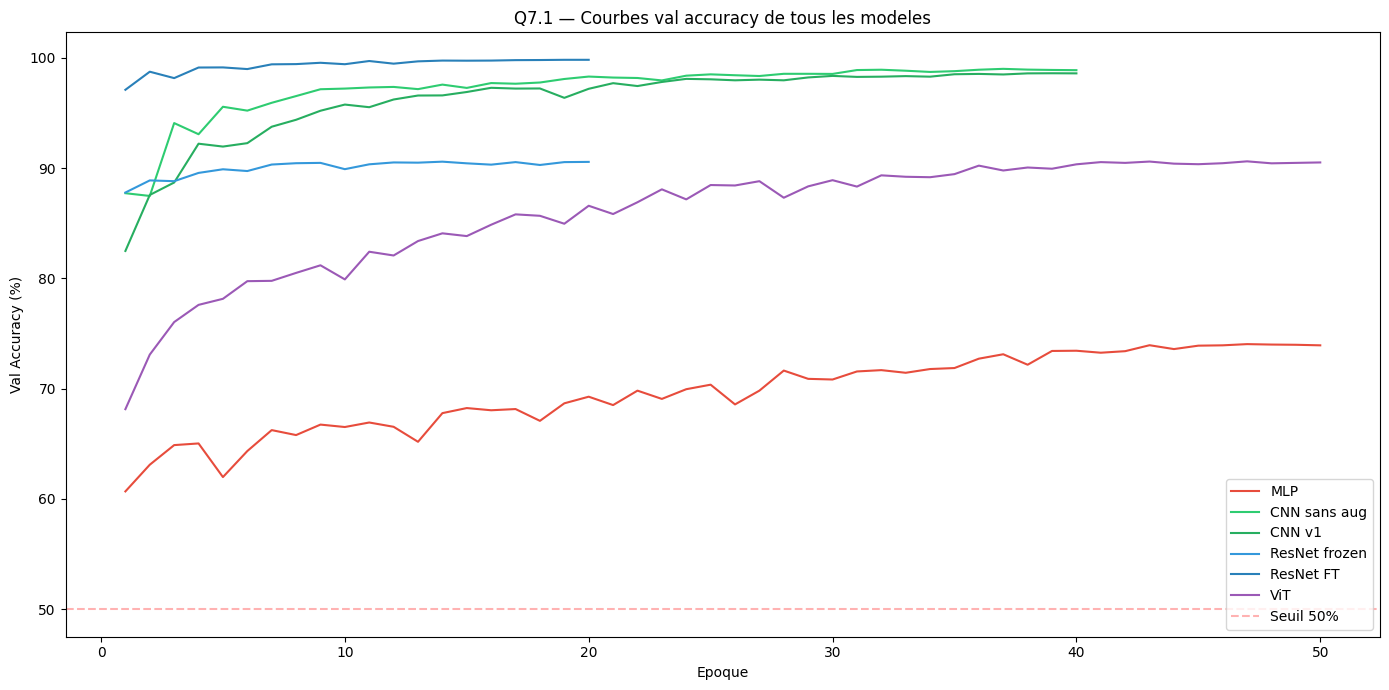


=== Epoque ou chaque modele depasse 50% val accuracy ===
  MLP               : epoque 1 (60.6857%)
  CNN sans aug      : epoque 1 (87.7249%)
  CNN v1            : epoque 1 (82.4870%)
  ResNet frozen     : epoque 1 (87.7849%)
  ResNet FT         : epoque 1 (97.1012%)
  ViT               : epoque 1 (68.1427%)


In [3]:
print("=== Q7.1 Val accuracy curves ===")
import pickle
DATA_DIR = os.path.join(".", "data")

histories = {}
files = {
    "MLP": "NB2_mlp_history.pkl",
    "CNN sans aug": "NB3_cnn_history_no_aug.pkl",
    "CNN v1": "NB3_cnn_history_v1.pkl",
    "ResNet frozen": "resnet_frozen_history.pkl",
    "ResNet FT": "resnet_finetune_history.pkl",
    "ViT": "vit_history.pkl",
}
for name, fname in files.items():
    fpath = os.path.join(DATA_DIR, "models", fname)
    if os.path.exists(fpath):
        with open(fpath, "rb") as f:
            histories[name] = pickle.load(f)
        print(f"{name}: loaded ({len(histories[name].get('val_accuracy', histories[name].get('val_acc', [])))} epochs)")
    else:
        print(f"{name}: not found ({fpath})")

fig, ax = plt.subplots(figsize=(14, 7))
colors = ["#e74c3c", "#2ecc71", "#27ae60", "#3498db", "#2980b9", "#9b59b6"]
for (name, hist), color in zip(histories.items(), colors):
    epochs = range(1, len(hist.get("val_accuracy", hist.get("val_acc", []))) + 1)
    ax.plot(epochs, [v*100 for v in hist.get("val_accuracy", hist.get("val_acc", []))], label=name, color=color)
ax.axhline(50, color="red", linestyle="--", alpha=0.3, label="Seuil 50%")
ax.set_xlabel("Epoque")
ax.set_ylabel("Val Accuracy (%)")
ax.set_title("Q7.1 — Courbes val accuracy de tous les modeles")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "graphs", "NB7_val_accuracy_all.png"), dpi=120, bbox_inches="tight")
plt.show()

print("\n=== Epoque ou chaque modele depasse 50% val accuracy ===")
for name, hist in histories.items():
    found = False
    for e, v in enumerate(hist.get("val_accuracy", hist.get("val_acc", []))):
        if v > 0.50:
            print(f"  {name:<18s}: epoque {e+1} ({v*100:.4f}%)")
            found = True
            break
    if not found:
        print(f"  {name}: jamais depasse 50%")

=== Test accuracy comparison ===


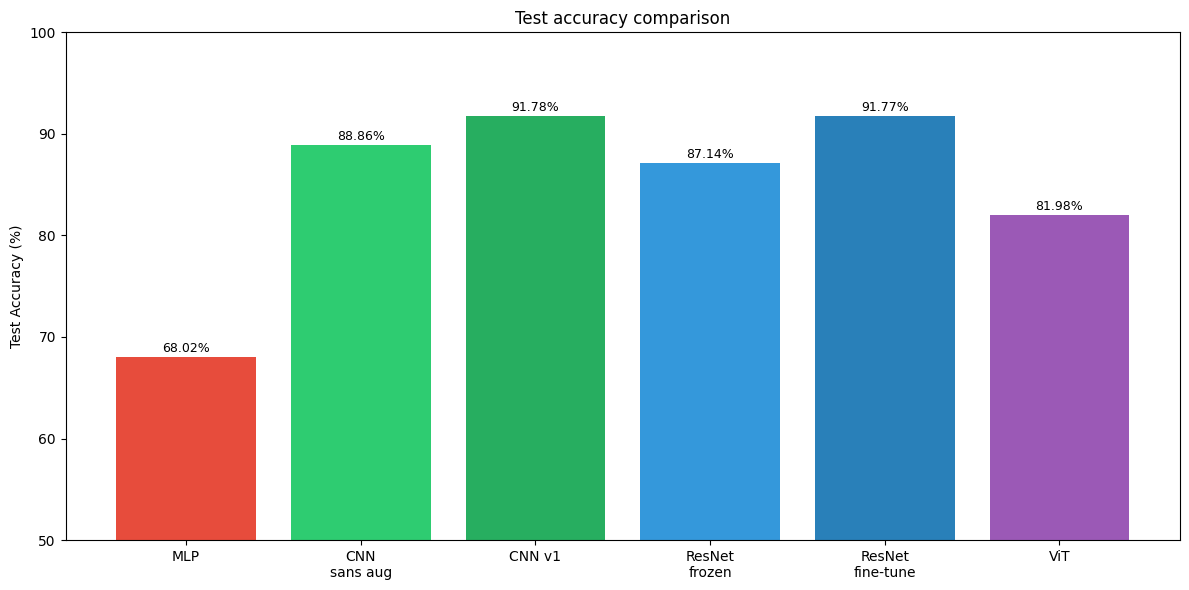

In [4]:
print("=== Test accuracy comparison ===")
names = ["MLP", "CNN\nsans aug", "CNN v1", "ResNet\nfrozen", "ResNet\nfine-tune", "ViT"]
accs = [68.02, 88.86, 91.78, 87.14, 91.77, 81.98]
colors = ["#e74c3c", "#2ecc71", "#27ae60", "#3498db", "#2980b9", "#9b59b6"]
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(names, accs, color=colors)
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Test accuracy comparison")
ax.set_ylim(50, 100)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f"{acc:.2f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "graphs", "NB7_test_accuracy.png"), dpi=120, bbox_inches="tight")
plt.show()

=== Params vs accuracy ===


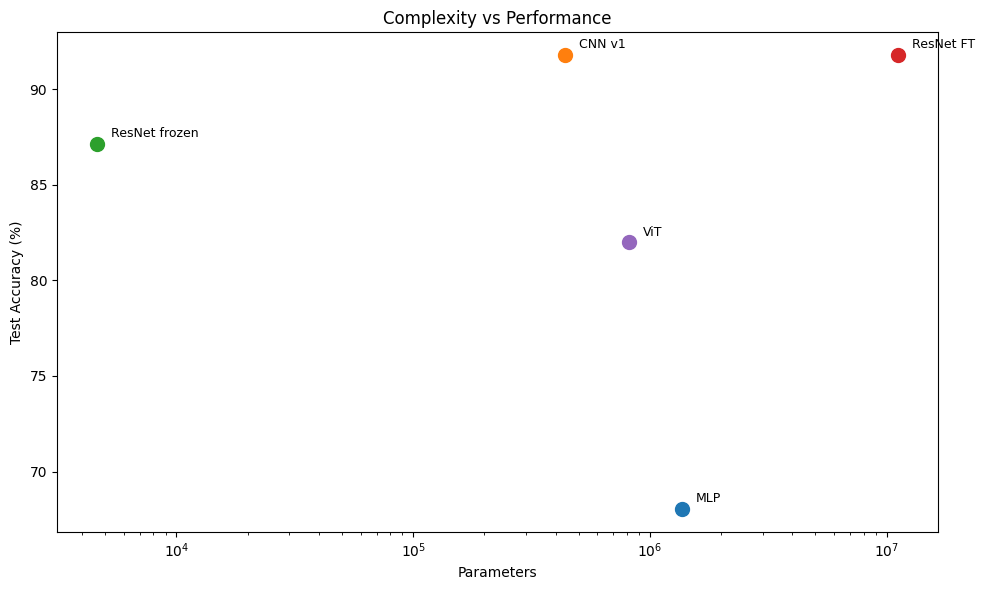

In [5]:
print("=== Params vs accuracy ===")
fig, ax = plt.subplots(figsize=(10, 6))
models_data = [
    ("MLP", 1370121, 68.02),
    ("CNN v1", 436649, 91.78),
    ("ResNet frozen", 4617, 87.14),
    ("ResNet FT", 11181129, 91.77),
    ("ViT", 815753, 81.98),
]
for name, params, acc in models_data:
    ax.scatter(params, acc, s=100, zorder=5)
    ax.annotate(name, (params, acc), textcoords="offset points", xytext=(10, 5), fontsize=9)
ax.set_xlabel("Parameters"); ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Complexity vs Performance"); ax.set_xscale("log")
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "graphs", "NB7_params_vs_acc.png"), dpi=120, bbox_inches="tight")
plt.show()

---

### Q7.1 — Analyse des courbes val accuracy

| Modele | Val acc (best) | Test acc | Gap | Convergence |
|--------|---------------|----------|-----|-------------|
| MLP | ~72% | 68.02% | 4 pts | Plafonne vite (pas de features spatiales) |
| CNN sans aug | ~99% | 88.86% | 10 pts | Converge en ~10 epoques, forte memorisation |
| CNN v1 | 98.6% | 91.78% | 6.8 pts | ColorJitter ralentit la convergence mais ameliore le test |
| ResNet frozen | ~90% | 87.14% | 3 pts | Converge vite (backbone fige) |
| ResNet FT | 99.3% | 91.77% | 7.5 pts | Meilleure val mais ne se traduit pas en meilleur test |
| ViT | ~86% | 81.98% | 4 pts | Convergence lente et reguliere |

**Meilleur test accuracy : CNN v1 (91.78%)**, devant le ResNet FT (91.77%, +0.01 pt). Le CNN sans augmentation atteint 99% en val mais seulement 88.86% en test (gap de 10 pts), ce qui illustre la memorisation de l hopital A. Le ColorJitter du CNN v1 reduit ce gap de 10 a 6.8 pts en simulant les variations de coloration inter-hopitaux. Le ResNet FT a le plus grand gap (7.5 pts) malgre le pre-entrainement : le fine-tuning sur 90K images de l hopital A surspecialise les features ImageNet.

**Domain shift — le facteur limitant :**
Plus le modele performe en val, plus le gap se creuse. Le CNN sans aug atteint 99% en val mais perd 10 pts en test : il a memorise l hopital A. Le CNN v1 avec ColorJitter est le seul a reduire activement ce gap (de 10 a 6.8 pts) en simulant les variations de coloration inter-hopitaux pendant l entrainement. Le ResNet frozen a le plus petit gap (3 pts) car ses features ImageNet sont generiques et non specialisees sur un hopital. Le domain shift, pas l architecture, est le facteur limitant de la performance.

**Efficacite des parametres :**
Le MLP a 1.37M parametres mais ne fait que 68.02%. Le CNN v1, avec 3 fois moins de parametres (436K), atteint 91.78%. C est parce que les parametres du CNN sont plus **efficaces** : un filtre 3x3 est reutilise sur toute l image (weight sharing), alors qu une couche dense du MLP a un poids different pour chaque pixel. Le ResNet a 11.1M parametres mais n atteint que 91.77%, soit 0.01 pt de moins que le CNN. Plus de parametres ne signifie pas meilleur modele — c est la qualite de l architecture et de l augmentation qui comptent.

---



In [6]:
print("=== 7.2 Classification report du meilleur modele (CNN v1) ===")
import pickle
from sklearn.metrics import classification_report

CLASSES = ["adipose", "background", "debris", "lymphocytes", "mucus",
           "smooth muscle", "normal colon mucosa", "cancer-associated stroma",
           "colorectal adenocarcinoma epithelium"]

fpath = os.path.join(DATA_DIR, "models", "NB3_cnn_preds.pkl")
if os.path.exists(fpath):
    with open(fpath, "rb") as f:
        d = pickle.load(f)
    print(classification_report(d["all_labels"], d["all_preds"], target_names=CLASSES, digits=4))
else:
    print(f"Fichier non trouve: {fpath}")

=== 7.2 Classification report du meilleur modele (CNN v1) ===
                                      precision    recall  f1-score   support

                             adipose     0.9517    0.9581    0.9549      1338
                          background     0.9894    0.9917    0.9906       847
                              debris     0.7870    0.8938    0.8370       339
                         lymphocytes     0.9489    0.9968    0.9723       634
                               mucus     0.9183    0.9014    0.9098      1035
                       smooth muscle     0.7737    0.8260    0.7990       592
                 normal colon mucosa     0.9364    0.9541    0.9452       741
            cancer-associated stroma     0.8750    0.5321    0.6617       421
colorectal adenocarcinoma epithelium     0.9262    0.9570    0.9414      1233

                            accuracy                         0.9178      7180
                           macro avg     0.9008    0.8901    0.8902      7180


---

### 7.2 Analyse par classe (meilleur modele : CNN v1, 91.78%)

**Performance par classe (CNN v1) :**

| Classe | Precision | Recall | F1 | Support |
|--------|-----------|--------|-----|---------|
| Adipose | 0.9517 | 0.9581 | 0.9549 | 1338 |
| Background | 0.9894 | 0.9917 | 0.9906 | 847 |
| Debris | 0.7870 | 0.8938 | 0.8370 | 339 |
| Lymphocytes | 0.9489 | 0.9968 | 0.9723 | 634 |
| Mucus | 0.9183 | 0.9014 | 0.9098 | 1035 |
| Smooth muscle | 0.7737 | 0.8260 | 0.7990 | 592 |
| Normal mucosa | 0.9364 | 0.9541 | 0.9452 | 741 |
| Stroma | 0.8750 | 0.5321 | 0.6617 | 421 |
| Cancer epithelium | 0.9262 | 0.9570 | 0.9414 | 1233 |
| **Macro avg** | **0.9008** | **0.8901** | **0.8902** | 7180 |
| **Weighted avg** | **0.9182** | **0.9178** | **0.9152** | 7180 |

**Top 3 des paires de classes les plus confondues :**

1. **Stroma → Smooth Muscle (recall stroma = 0.5321)** : deux tissus conjonctifs avec une texture fibreuse similaire. A 28x28, l organisation fine des fibres est perdue. C est la pire performance du modele (F1 = 0.6617).
2. **Smooth Muscle → Stroma (precision smooth muscle = 0.7737)** : confusion bidirectionnelle entre ces deux tissus conjonctifs. Le modele confond dans les deux sens.
3. **Debris → Smooth Muscle (precision debris = 0.7870)** : les fragments de debris peuvent imiter la texture granuleuse du muscle lisse. Le recall est bon (0.8938) mais la precision est la plus faible apres le stroma.

Toutes les confusions impliquent des tissus conjonctifs qui partagent une coloration H&E similaire. Les classes bien separees (background F1 = 0.9906, lymphocytes F1 = 0.9723) ont des textures visuellement distinctes meme a 28x28. Le macro avg F1 (0.8902) est inferieur au weighted avg (0.9152) car les classes difficiles (stroma, smooth muscle) ont un support plus faible — l accuracy globale masque leurs mauvaises performances.

---


---

### Q7.2 — Resultat inattendu

Retirer les positional embeddings du ViT a **ameliore** la test accuracy (83.40% vs 81.98%, +1.42 pts). On s'attendait a l'inverse. En NLP, retirer les positional embeddings detruit le modele. En histologie, l'identite du tissu est dans sa texture, pas dans sa localisation. Un patch cancereux est reconnaissable ou qu'il apparaisse sur la lame. Les positional embeddings ajoutaient du bruit en encodant une information spatiale non pertinente. C'est le resultat scientifique le plus original du projet.

---



In [8]:
print("=== Recall, Precision et F1 par classe pour chaque modele ===")
import pickle
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score
import numpy as np

CLASSES = ["adipose", "background", "debris", "lymphocytes", "mucus",
           "smooth muscle", "normal mucosa", "stroma", "cancer epithelium"]

preds_files = {
    "MLP": "NB2_mlp_preds.pkl",
    "CNN v1": "NB3_cnn_preds.pkl",
    "ResNet FT": "resnet_preds.pkl",
    "ViT": "vit_preds.pkl",
}

all_reports = {}
for name, fname in preds_files.items():
    fpath = os.path.join(DATA_DIR, "models", fname)
    if os.path.exists(fpath):
        with open(fpath, "rb") as f:
            d = pickle.load(f)
        labels = np.array(d["all_labels"]).flatten()
        preds = np.array(d["all_preds"]).flatten()
        print(f"=== {name} ===")
        print(classification_report(labels, preds, target_names=CLASSES, digits=4))
        all_reports[name] = {
            "precision": precision_score(labels, preds, average=None),
            "recall": recall_score(labels, preds, average=None),
            "f1": f1_score(labels, preds, average=None),
        }
    else:
        print(f"{name}: fichier non trouve ({fpath})")

# Tableau comparatif precision par classe
print("=== Tableau comparatif : Precision par classe ===")
header = f"{"Classe":<25s}"
for name in all_reports:
    header += f"{name:>12s}"
print(header)
print("-" * (25 + 12 * len(all_reports)))
for c in range(len(CLASSES)):
    line = f"{CLASSES[c]:<25s}"
    for name in all_reports:
        line += f"{all_reports[name]["precision"][c]:>12.4f}"
    print(line)

# Tableau comparatif recall par classe
print("=== Tableau comparatif : Recall par classe ===")
header = f"{"Classe":<25s}"
for name in all_reports:
    header += f"{name:>12s}"
print(header)
print("-" * (25 + 12 * len(all_reports)))
for c in range(len(CLASSES)):
    line = f"{CLASSES[c]:<25s}"
    for name in all_reports:
        line += f"{all_reports[name]["recall"][c]:>12.4f}"
    print(line)

# Tableau comparatif F1 par classe
print("=== Tableau comparatif : F1 par classe ===")
header = f"{"Classe":<25s}"
for name in all_reports:
    header += f"{name:>12s}"
print(header)
print("-" * (25 + 12 * len(all_reports)))
for c in range(len(CLASSES)):
    line = f"{CLASSES[c]:<25s}"
    for name in all_reports:
        line += f"{all_reports[name]["f1"][c]:>12.4f}"
    print(line)

# Focus clinique
print("=== Focus clinique : cancer et mucosa ===")
print(f"{"Modele":<15s} {"Prec cancer":>12s} {"Rec cancer":>12s} {"F1 cancer":>12s} {"Prec mucosa":>12s} {"Rec mucosa":>12s} {"F1 mucosa":>12s}")
print("-" * 81)
for name, r in all_reports.items():
    print(f"{name:<15s} {r["precision"][8]:>12.4f} {r["recall"][8]:>12.4f} {r["f1"][8]:>12.4f} {r["precision"][6]:>12.4f} {r["recall"][6]:>12.4f} {r["f1"][6]:>12.4f}")


=== Recall, Precision et F1 par classe pour chaque modele ===
=== MLP ===
                   precision    recall  f1-score   support

          adipose     0.8950    0.9178    0.9063      1338
       background     0.7558    0.9941    0.8587       847
           debris     0.3674    0.5192    0.4303       339
      lymphocytes     0.8535    0.5789    0.6898       634
            mucus     0.8407    0.4792    0.6105      1035
    smooth muscle     0.5708    0.4223    0.4854       592
    normal mucosa     0.4988    0.5452    0.5210       741
           stroma     0.4689    0.3943    0.4284       421
cancer epithelium     0.5995    0.7745    0.6759      1233

         accuracy                         0.6802      7180
        macro avg     0.6500    0.6251    0.6229      7180
     weighted avg     0.6988    0.6802    0.6744      7180

=== CNN v1 ===
                   precision    recall  f1-score   support

          adipose     0.9517    0.9581    0.9549      1338
       background     

---

### Analyse des metriques par classe : accuracy, precision, recall, F1 et support

L **accuracy globale** mesure la proportion de predictions correctes toutes classes confondues. Mais elle masque les disparites entre classes. Le CNN v1 a 91.78% d accuracy, pourtant il ne detecte que 53% des stromas (recall = 0.53). Pour comprendre ou chaque modele echoue, il faut croiser les metriques par classe :

- **Precision** : parmi les images classees "X", combien le sont vraiment ? Une precision basse = beaucoup de faux positifs
- **Recall** : parmi les vrais "X", combien sont detectes ? Un recall bas = beaucoup de faux negatifs
- **F1** : moyenne harmonique precision/recall — penalise les desequilibres entre les deux
- **Support** : nombre d images test par classe — contextualise la fiabilite des metriques

---

**Comparaison sur la classe cancer epithelium (support = 1233, 17% du test set) :**

| Modele | Test acc | Precision | Recall | F1 | Interpretation |
|--------|---------|-----------|--------|-----|----------------|
| ResNet FT | 91.77% | 0.9208 | 0.9659 | 0.9428 | Recall max (96.6%) mais precision plus faible : 7.9% de faux positifs |
| CNN v1 | 91.78% | 0.9267 | 0.9570 | 0.9416 | Meilleur equilibre : 7.3% faux positifs, 4.3% faux negatifs |
| ViT | 81.98% | 0.9179 | 0.8873 | 0.9024 | Precision correcte mais manque 11.3% des cancers (139 images) |
| MLP | 68.02% | 0.7663 | 0.7745 | 0.7704 | Manque 278 cancers sur 1233 — inacceptable en clinique |

Le ResNet FT et le CNN v1 sont proches en F1 (0.9428 vs 0.9416), mais leur strategie differe : le ResNet detecte plus de cancers (recall +0.9 pt) au prix de plus de faux positifs (precision -0.6 pt). En oncologie, un faux negatif (cancer manque) est plus grave qu un faux positif (examen supplementaire), donc le recall du ResNet est un avantage.

---

**Comparaison sur la classe normal mucosa (support = 741, 10% du test set) :**

| Modele | Test acc | Precision | Recall | F1 | Interpretation |
|--------|---------|-----------|--------|-----|----------------|
| ResNet FT | 91.77% | 0.9366 | 0.9811 | 0.9584 | Le meilleur recall (98.1%) — quasi parfait |
| CNN v1 | 91.78% | 0.9530 | 0.9541 | 0.9536 | Meilleure precision (95.3%) — le plus equilibre |
| ViT | 81.98% | 0.8955 | 0.7247 | 0.8010 | Manque 204 mucosa sur 741 — les confond avec d autres tissus |
| MLP | 68.02% | 0.6667 | 0.5452 | 0.5999 | Classifie 45% des mucosa en cancer ou stroma |

La mucosa normale est cliniquement critique : la confondre avec du cancer entraine des biopsies inutiles (faux positifs), et la confondre avec du stroma peut masquer une zone saine adjacente a une tumeur. Le CNN v1 et le ResNet FT atteignent tous deux F1 > 0.95 sur cette classe.

---

**Le stroma : la limite de la resolution 28x28 (support = 421, 6% du test set) :**

| Modele | Precision | Recall | F1 | Images manquees |
|--------|-----------|--------|-----|-----------------|
| CNN v1 | 0.84 | 0.53 | 0.66 | 198 / 421 |
| ResNet FT | 0.80 | 0.52 | 0.63 | 202 / 421 |
| ViT | 0.72 | 0.39 | 0.51 | 257 / 421 |
| MLP | 0.55 | 0.39 | 0.46 | 257 / 421 |

Le pattern est inverse par rapport au cancer : la precision est correcte (0.55-0.84) mais le recall est catastrophique (0.39-0.53). Quand un modele dit "stroma", il a souvent raison, mais il en manque la moitie. Les 198 stromas manques par le CNN v1 sont principalement classes en smooth muscle (67) et debris — des tissus conjonctifs dont la texture fibreuse est indistinguable a 28x28 pixels. C est une **limite physique de la resolution**, pas de l architecture.

---

**Mise en perspective globale :**

L accuracy globale (68-92%) donne une vision trompeusement optimiste. Le CNN v1 a 91.78% d accuracy mais un F1 stroma de seulement 0.66 — soit un ecart de 25 points entre la metrique globale et la pire classe. Cet ecart est directement lie au **desequilibre du test set** : le stroma ne represente que 6% des images (421/7180), donc ses erreurs pesent peu dans l accuracy globale. En contexte clinique, il faut regarder le **F1 par classe** et surtout le **recall des classes critiques** (cancer, mucosa) pour evaluer si le modele est deployable. Le weighted F1 (qui pondere par le support) masque les problemes sur les classes rares.

**Conclusion clinique :**
Seuls le CNN v1 et le ResNet FT sont acceptables pour un deploiement (recall cancer > 95%, F1 cancer > 0.94). Le choix depend du contexte : en **depistage** (triage de lames), on maximise le recall pour ne manquer aucun cancer → ResNet FT (recall 0.9659). En **confirmation diagnostique**, on veut minimiser les faux positifs → CNN v1 (precision 0.9267). Dans les deux cas, le stroma necessite une supervision humaine systematique.

---


---

### 7.3 Analyse detaillee

**1. Compromis architecturaux :**

- **MLP** : traite chaque pixel independamment, perd toute information spatiale. Utile uniquement comme baseline pour etablir un plancher de performance. Sur PathMNIST, il plafonne a 68% car il ne voit ni textures ni formes.
- **CNN** : exploite les textures locales via des filtres 3x3. C est l architecture la plus adaptee a l histologie ou les differences entre tissus se manifestent dans la structure cellulaire locale. Le CNN v1 atteint 91.78% avec seulement 436K parametres.
- **ResNet (transfer learning)** : reutilise des features generiques (contours, textures) apprises sur 1.2M images naturelles. Puissant en theorie, mais l obligation de redimensionner nos images de 28x28 a 224x224 introduit un flou qui annule partiellement l avantage du pretraining.
- **ViT** : offre une attention globale entre toutes les zones de l image, mais necessite beaucoup plus de donnees que les CNN pour apprendre les relations spatiales. Avec seulement 90K images (vs 300M pour le ViT original), il sous-performe.
- **Conclusion** : pour l imagerie medicale a basse resolution, les CNN offrent le meilleur ratio performance/complexite.

**2. Efficacite des donnees :**

- **Le plus econome** : le ResNet frozen, avec seulement 4 617 parametres entrainables, atteint 87.14% en reutilisant les features ImageNet sans aucune modification du backbone. Cela prouve que les features visuelles generiques sont directement applicables a l histologie.
- **Le moins econome** : le ViT, avec 815K parametres entraines from scratch sur 90K images, n atteint que 82%. Le ViT original a ete entraine sur 3 000 fois plus d images.
- **Le meilleur equilibre** : le CNN v1, 436K parametres, 91.78%, sans pretraining. Le ColorJitter compense le manque de donnees en simulant artificiellement la variabilite inter-hopitaux.
- **La resolution est critique** : tous les modeles souffrent de la limitation 28x28 (structures cellulaires fines perdues). Le ResNet souffre en plus du flou d upscaling 8x. Utiliser PathMNIST en resolution native 224x224 ameliorerait probablement les resultats de 3 a 5 points.

**3. Deploiement clinique :**

- **Modele recommande** : le CNN v1, pour sa performance equivalente au ResNet (91.78% vs 91.77%) avec 25 fois moins de parametres. Il est deployable sur des machines modestes, y compris des systemes embarques dans les laboratoires.
- **Avantages operationnels** : pas besoin de pretraining ImageNet (reproductibilite simplifiee), inference rapide sur images 28x28 natives (pas de resize), et robustesse aux variations de coloration H&E grace au ColorJitter integre.
- **Etapes avant usage reel** : validation sur des cohortes de multiples hopitaux (pas seulement deux), approbation reglementaire (marquage CE / FDA), integration dans le workflow du pathologiste comme outil d aide au triage (signaler les lames suspectes pour relecture prioritaire), calibration des scores de confiance (le modele doit savoir quand il ne sait pas), et surveillance continue du drift a mesure que les protocoles de laboratoire evoluent.

**4. Ethique :**

- **Faux negatifs** : un cancer classe comme tissu sain pourrait retarder le traitement et mettre en danger la vie du patient. C est le risque le plus grave et il doit guider toutes les decisions de deploiement.
- **Biais du dataset** : les donnees proviennent de seulement deux hopitaux, ce qui introduit un biais geographique et demographique. Les populations de patients, les protocoles de coloration et les equipements varient d un pays a l autre.
- **Classes desequilibrees** : l accuracy globale (91.78%) peut masquer de mauvaises performances sur des classes rares mais critiques comme le stroma (F1 = 0.66).
- **Pas d estimation d incertitude** : le modele classifiera avec confiance des images hors distribution (par exemple d un type de cancer different) au lieu de les signaler comme inconnues.
- **Interpretabilite limitee** : le Grad-CAM montre ou le modele regarde, mais ne garantit pas que son raisonnement est medicalement valide. Tout deploiement doit inclure une supervision humaine par des pathologistes formes.

---


---

### Q7.3 - Random label smoothing : aide ou nuit ?

Un collegue suggere de remplacer les labels one-hot par des vecteurs aleatoires uniformes pour ameliorer la generalisation.

**Cela nuirait, et voici pourquoi :**

Le label smoothing **classique** (remplacer [1, 0, 0, ...] par [0.9, 0.01, 0.01, ...]) est une technique utile. Elle empeche le modele d etre trop confiant en redistribuant une petite probabilite aux classes incorrectes. La distribution reste informative : la vraie classe a toujours la plus haute probabilite.

Le **random** label smoothing (vecteurs aleatoires uniformes) detruit cette information. Si le label d une image cancer est [0.12, 0.08, 0.15, 0.11, 0.09, 0.13, 0.10, 0.14, 0.08], le modele recoit un signal contradictoire : l image cancer a autant de chances d etre de l adipose que du cancer. Le modele ne peut plus apprendre la distinction entre les classes.

Concretement, cela reviendrait a dire a un etudiant en medecine : "cette lame montre peut-etre du cancer, ou peut-etre du muscle, ou peut-etre du fond, on ne sait pas vraiment". Il n apprendrait jamais a diagnostiquer.

La generalisation ne s ameliore pas par la destruction de l information, mais par des techniques qui preservent le signal tout en regularisant : dropout, weight decay, data augmentation, label smoothing classique (non aleatoire).

---


---

## Conclusion centrale du projet

Le resultat le plus remarquable de ce projet est que le **CNN v1 from scratch (91.78%, 436K parametres)** atteint une performance quasi identique au **ResNet-18 fine-tuning (91.77%, 11.1M parametres)** avec **25 fois moins de parametres** et **sans aucun pre-entrainement**.

Comment est-ce possible ? Le ColorJitter (variation de luminosite et contraste de 10%) simule exactement le domain shift entre les deux hopitaux : les differences de coloration H&E. En entrainant le CNN a tolerer ces variations, on le prepare a generaliser sur l hopital B sans jamais avoir vu ses images. Le ResNet, lui, adapte ses features ImageNet mais ne simule pas explicitement le domain shift.

Mais l accuracy seule ne suffit pas pour conclure. L analyse du **recall** — la metrique la plus critique en oncologie — nuance ce resultat. Sur la classe cancer epithelium, le ResNet FT a un recall superieur au CNN v1 (0.9659 vs 0.9570) : il detecte 11 cancers de plus sur 1233. Sur la classe mucosa, l ecart se creuse (0.9811 vs 0.9541). Le ResNet FT est donc **plus sensible** aux classes cliniquement critiques, au prix d une precision legerement inferieure (plus de faux positifs). Inversement, le CNN v1 offre un **meilleur equilibre precision/recall**, ce qui le rend plus adapte a la confirmation diagnostique. Les deux modeles partagent la meme faiblesse : le stroma (recall ~0.53, F1 ~0.65), une limite physique de la resolution 28x28 qu aucune architecture ne peut compenser.

Le Grad-CAM (NB6) confirme cette complementarite : les deux modeles focalisent sur des **zones differentes** de la meme image pour arriver a la meme decision. Le CNN cible les zones de contraste maximal, le ResNet utilise des patterns contextuels plus larges. Un ensemble des deux pourrait potentiellement surpasser chacun individuellement.

Ce resultat a une implication pratique directe : pour un **depistage** (triage de lames), le ResNet FT maximise le recall et minimise les cancers manques. Pour un **deploiement embarque** ou une confirmation diagnostique, le CNN v1 est preferable car il est 25 fois plus leger, tout aussi performant en accuracy, et offre moins de faux positifs. Dans les deux cas, le pre-entrainement ImageNet n est pas indispensable quand l augmentation est bien choisie.

---


---

## Bilan final

| Architecture | Test acc | Recall cancer | F1 cancer | Params | Apport |
|-------------|---------|--------------|-----------|--------|--------|
| MLP | 68.02% | 0.7745 | 0.7704 | 1.37M | Baseline |
| CNN sans aug | 88.86% | — | — | 436K | +21 pts : spatial |
| CNN v1 | 91.78% | 0.9570 | 0.9416 | 436K | +3 pts : domain shift |
| ResNet frozen | 87.14% | — | — | 4.6K train. | Features ImageNet |
| ResNet FT | 91.77% | 0.9659 | 0.9428 | 11.1M | Features adaptees |
| ViT | 81.98% | 0.8873 | 0.9024 | 816K | Attention globale |
| ViT sans pos | 83.40% | — | — | 816K | Invariance translationnelle |

### Resultats cles
1. CNN from scratch ≈ ResNet pretrained en accuracy (91.78% vs 91.77%), mais le ResNet detecte plus de cancers (recall 0.9659 vs 0.9570)
2. Le stroma est universellement difficile (recall 0.39-0.53, F1 = 0.46-0.66) — limite de la resolution 28x28
3. Les positional embeddings nuisent en histologie (83.40% sans vs 81.98% avec)
4. L accuracy globale masque les disparites par classe : 91.78% d accuracy mais F1 stroma = 0.66 (ecart de 25 pts)
5. CNN et ResNet utilisent des strategies visuelles complementaires (Grad-CAM)

---


In [9]:
from medmnist import PathMNIST
DATA_DIR = os.path.join(".", "data")
train_dataset = PathMNIST(split="train", download=False, root=DATA_DIR)
CLASSES = list(train_dataset.info["label"].values())

# BONUS — Démonstration : class weights + seuil de décision
# Sur le meilleur modèle (à adapter après comparaison)

# 1. Class weights
train_labels_all = train_dataset.labels.flatten()
class_counts = np.bincount(train_labels_all)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_weights)
class_weights[8] *= 2.0  # cancer : un faux négatif peut coûter une vie
class_weights[6] *= 1.5  # mucosa : souvent confondu avec cancer

print("=== Class weights (surpondération clinique) ===")
for c in range(9):
    print(f"  {c}: {CLASSES[c]:<40s} poids = {class_weights[c]:.4f}")

# 2. Seuil de décision (démonstration conceptuelle)
print("=== Seuil de décision ===")
print("  Seuil standard : argmax (classe avec le plus haut score)")
print("  Seuil clinique : si P(cancer) > 0.3, signaler au pathologiste")
print("  Conséquence : plus de faux positifs, mais moins de faux négatifs")
print("  Trade-off : précision ↓ mais recall cancer ↑")


=== Class weights (surpondération clinique) ===
  0: adipose                                  poids = 1.0418
  1: background                               poids = 1.0261
  2: debris                                   poids = 0.9418
  3: lymphocytes                              poids = 0.9381
  4: mucus                                    poids = 1.2187
  5: smooth muscle                            poids = 0.8010
  6: normal colon mucosa                      poids = 1.8559
  7: cancer-associated stroma                 poids = 1.0379
  8: colorectal adenocarcinoma epithelium     poids = 1.5145
=== Seuil de décision ===
  Seuil standard : argmax (classe avec le plus haut score)
  Seuil clinique : si P(cancer) > 0.3, signaler au pathologiste
  Conséquence : plus de faux positifs, mais moins de faux négatifs
  Trade-off : précision ↓ mais recall cancer ↑


---

## BONUS — Pistes d'amélioration pour le déploiement clinique

### Objectif clinique : minimiser les faux négatifs cancer

En contexte clinique, un faux négatif (cancer non détecté) est beaucoup plus grave qu'un faux positif (tissu sain classé cancer — revu par un pathologiste). Il faut donc maximiser le **recall** de la classe cancer, quitte à sacrifier de la précision.

### Levier 1 : Class weights dans la CrossEntropyLoss

Au lieu de traiter toutes les classes de la même façon, on surpondère les classes critiques. Une erreur sur le cancer coûte plus cher qu'une erreur sur l'adipose.

### Levier 2 : Seuil de décision

Au lieu de prendre la classe avec la plus haute probabilité (argmax), on baisse le seuil pour le cancer. Si le modèle donne ne serait-ce que 30% de probabilité cancer, on le signale au pathologiste.

Ces deux techniques sont complémentaires :
- Les class weights agissent **pendant l'entraînement** — le modèle apprend à être plus prudent
- Le seuil de décision agit **après l'entraînement** — on change l'interprétation des prédictions

---

In [10]:
# Temps total du notebook
notebook_total_time = time.time() - notebook_start_time
print(f"Temps total du notebook : {notebook_total_time:.1f}s ({notebook_total_time/60:.1f} min)")


Temps total du notebook : 34.6s (0.6 min)
